## Step 1: Import Libraries

In [29]:
import pandas as pd
import numpy as np
import joblib
import os
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


## Step 2: Load Training Data

In [30]:
# Set path to your training dataset CSV
training_csv = r"E:\ML\silero-python\_training_dataset.csv"

# Load the data
print(f"Loading training data from: {training_csv}")
df = pd.read_csv(training_csv)

# Shuffle the data randomly so Control/MCI are mixed
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\nData loaded and shuffled successfully!")
print(f"Total patients: {len(df)}")
print(f"\nFirst few rows:")
print(df.tail())

Loading training data from: E:\ML\silero-python\_training_dataset.csv

Data loaded and shuffled successfully!
Total patients: 1248

First few rows:
      pause_count  total_speech_time  total_pause_time  mean_word_duration  \
1243          578            264.454            48.429              0.3386   
1244         1341            675.694           144.879              0.3553   
1245          765            325.694            47.456              0.3243   
1246          768            359.142           135.141              0.2566   
1247         1020            430.521            75.056              0.3177   

      speech_rate_wpm  pause_per_word_ratio         patient_id  diagnosis  \
1243           177.20                0.2476           14-1-v03          1   
1244           168.87                0.2256          327-1-v01          1   
1245           185.02                0.2121          329-1-v02          1   
1246           233.84                0.7526  mci_aug_0142_09-2          1  

## Step 3: Check Diagnosis Distribution

In [31]:
print("Diagnosis Distribution:")
print(df['diagnosis_name'].value_counts())
print(f"\nPercentages:")
print(df['diagnosis_name'].value_counts(normalize=True) * 100)

Diagnosis Distribution:
diagnosis_name
MCI        658
Control    590
Name: count, dtype: int64

Percentages:
diagnosis_name
MCI        52.724359
Control    47.275641
Name: proportion, dtype: float64


## Step 4: Extract Features and Labels

In [32]:
# Extract feature columns (all except patient_id, diagnosis, diagnosis_name)
feature_cols = [col for col in df.columns if col not in ['patient_id', 'diagnosis', 'diagnosis_name' ]]

print(f"Total features: {len(feature_cols)}")
print(f"\nFeatures being used:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i}. {col}")

Total features: 6

Features being used:
  1. pause_count
  2. total_speech_time
  3. total_pause_time
  4. mean_word_duration
  5. speech_rate_wpm
  6. pause_per_word_ratio


## Step 5: Prepare X (features) and y (labels)

In [33]:
# X = features, y = diagnosis labels
X = df[feature_cols].astype(float)
y = df['diagnosis'].astype(int)

print(f"X shape (samples × features): {X.shape}")
print(f"y shape (labels): {y.shape}")
print(f"\nFeature statistics:")
print(X.describe())

X shape (samples × features): (1248, 6)
y shape (labels): (1248,)

Feature statistics:
       pause_count  total_speech_time  total_pause_time  mean_word_duration  \
count  1248.000000        1248.000000       1248.000000         1248.000000   
mean    985.862179         416.778729        137.619279            0.258615   
std     432.354560         186.118164         82.240414            0.057560   
min     222.000000          87.010000         14.948000            0.100800   
25%     657.000000         269.262000         77.953000            0.219475   
50%     913.000000         384.321500        122.279500            0.238050   
75%    1264.000000         524.410000        176.048000            0.308275   
max    2442.000000        1344.423000        711.787000            0.413700   

       speech_rate_wpm  pause_per_word_ratio  
count      1248.000000           1248.000000  
mean        242.994728              0.666723  
std          51.574193              0.277006  
min         1

## Step 6: Split Data into Train and Test Sets

In [34]:
# Split: 80% training, 20% testing
# stratify=y ensures same diagnosis distribution in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)} patients")
print(f"Test set size: {len(X_test)} patients")
print(f"\nTraining set diagnosis distribution:")
print(y_train.value_counts())
print(f"\nTest set diagnosis distribution:")
print(y_test.value_counts())

Training set size: 998 patients
Test set size: 250 patients

Training set diagnosis distribution:
diagnosis
1    526
0    472
Name: count, dtype: int64

Test set diagnosis distribution:
diagnosis
1    132
0    118
Name: count, dtype: int64


## Step 7: Scale the Features

In [35]:
# Standardize features (mean=0, std=1)
# Important because pause_duration (seconds) and word_count have different scales
print("Scaling features using StandardScaler...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete!")
print(f"\nScaled training data statistics:")
print(f"Mean: {X_train_scaled.mean(axis=0)[:3]}...")  # Show first 3
print(f"Std:  {X_train_scaled.std(axis=0)[:3]}...")

Scaling features using StandardScaler...
Scaling complete!

Scaled training data statistics:
Mean: [4.98376668e-17 5.33975002e-17 1.99350667e-16]...
Std:  [1. 1. 1.]...


### testing on my data

In [9]:
data = pd.read_csv(r'E:\ML\silero-python\training_dataset_Bracrest.csv')
# print(data.head())

X = data[feature_cols].astype(float)
y = data['diagnosis'].astype(int)
# print(X)
a_train, a_test, b_train, b_test  = train_test_split(
    X, y, test_size=0.11, random_state=42, stratify=y
)
a_train_scaled = scaler.fit_transform(a_train)
print(a_train_scaled)


FileNotFoundError: [Errno 2] No such file or directory: 'E:\\ML\\silero-python\\training_dataset_Bracrest.csv'

## Step 8: Train Random Forest Model

In [37]:
# Initialize and train Random Forest with SIMPLIFIED parameters


model = RandomForestClassifier(
    n_estimators=200,  # Reasonable number of trees
    max_depth=5,  # Reduced from 5 - simpler trees
    min_samples_split=10,  # Increased from 5 - prevent overfitting
    min_samples_leaf=5,  # Increased from 2 - larger leaves
    random_state=42,
    n_jobs=-1,
    class_weight="balanced",
)

model.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=5, min_samples_leaf=5,
                       min_samples_split=10, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [38]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

print("\n4. Training SVM...")
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
svm_acc = accuracy_score(y_test, svm_pred)

print(f"   Accuracy: {svm_acc:.4f} ({svm_acc*100:.2f}%)")


4. Training SVM...
   Accuracy: 0.7800 (78.00%)


## Step 9: Make Predictions

In [39]:
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
# print(y_test_pred)
# print(y_test)

print(f"True labels:       {y_test.values[:20]}")
print(f"Predicted labels:  {y_test_pred[:20]}")

True labels:       [0 1 0 0 0 0 1 1 0 0 0 1 1 1 1 0 0 0 1 1]
Predicted labels:  [1 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 1 1]


In [40]:
# Predict on training and test data
# model = svm_model
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)
# print(y_test_pred)
# print(y_test)

print(f"True labels:       {y_test.values[:20]}")
print(f"Predicted labels:  {y_test_pred[:20]}")
# print(b_train.values)
# print(y_test_pred)


True labels:       [0 1 0 0 0 0 1 1 0 0 0 1 1 1 1 0 0 0 1 1]
Predicted labels:  [1 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 1 0 1 1]


## Step 10: Evaluate Model Performance

In [41]:
print("\n" + "="*80)
print("MODEL PERFORMANCE METRICS")
print("="*80)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\nAccuracy:")
print(f"  Training: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"  Test:     {test_acc:.4f} ({test_acc*100:.2f}%)")

print(f"\nDetailed Test Set Metrics:")
print(f"  Precision: {precision_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"  Recall:    {recall_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_test_pred, average='weighted'):.4f}")


MODEL PERFORMANCE METRICS

Accuracy:
  Training: 0.8387 (83.87%)
  Test:     0.7720 (77.20%)

Detailed Test Set Metrics:
  Precision: 0.7902
  Recall:    0.7720
  F1-Score:  0.7704


## Step 11: Cross-Validation

In [42]:
# 5-fold cross-validation
cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')

print("5-Fold Cross-Validation:")
print(f"  Fold scores: {cv_scores}")
print(f"  Mean: {cv_scores.mean():.4f}")
print(f"  Std Dev: {cv_scores.std():.4f}")

5-Fold Cross-Validation:
  Fold scores: [0.79       0.83       0.78       0.77386935 0.81407035]
  Mean: 0.7976
  Std Dev: 0.0212


## Step 12: Confusion Matrix

In [43]:
cm = confusion_matrix(y_test, y_test_pred)

print("\nConfusion Matrix:")
print("(Rows=True labels, Columns=Predicted labels)\n")

diagnosis_names = {0: 'Control', 1: 'MCI'}
print("     Control  MCI    AD")
for i, row in enumerate(cm):
    print(f"{diagnosis_names[i]:<8} {row[0]:<8} {row[1]:<8}")


Confusion Matrix:
(Rows=True labels, Columns=Predicted labels)

     Control  MCI    AD
Control  104      14      
MCI      43       89      


## Step 13: Detailed Classification Report

In [44]:
print("\nDetailed Classification Report:")
diagnosis_names = {0: 'Control', 1: 'MCI'}
report = classification_report(
    y_test, y_test_pred, 
    target_names=[diagnosis_names[i] for i in range(2)]
)
print(report)


Detailed Classification Report:
              precision    recall  f1-score   support

     Control       0.71      0.88      0.78       118
         MCI       0.86      0.67      0.76       132

    accuracy                           0.77       250
   macro avg       0.79      0.78      0.77       250
weighted avg       0.79      0.77      0.77       250



## Step 14: Feature Importance

In [22]:
# Get feature importance from the trained model
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))

print("\nAll Features (sorted by importance):")
print(feature_importance.to_string(index=False))

AttributeError: 'SVC' object has no attribute 'feature_importances_'

## Step 15: Visualize Feature Importance

In [45]:
# Plot top 10 features
plt.figure(figsize=(10, 6))
top_features = feature_importance.head(10)
plt.barh(range(len(top_features)), top_features['importance'].values)
plt.yticks(range(len(top_features)), top_features['feature'].values)
plt.xlabel('Importance')
plt.title('Top 10 Most Important Features for AD/MCI Detection')
plt.tight_layout()
plt.show()

print("Feature importance plot displayed!")

NameError: name 'feature_importance' is not defined

<Figure size 1000x600 with 0 Axes>

## Step 16: Visualize Confusion Matrix

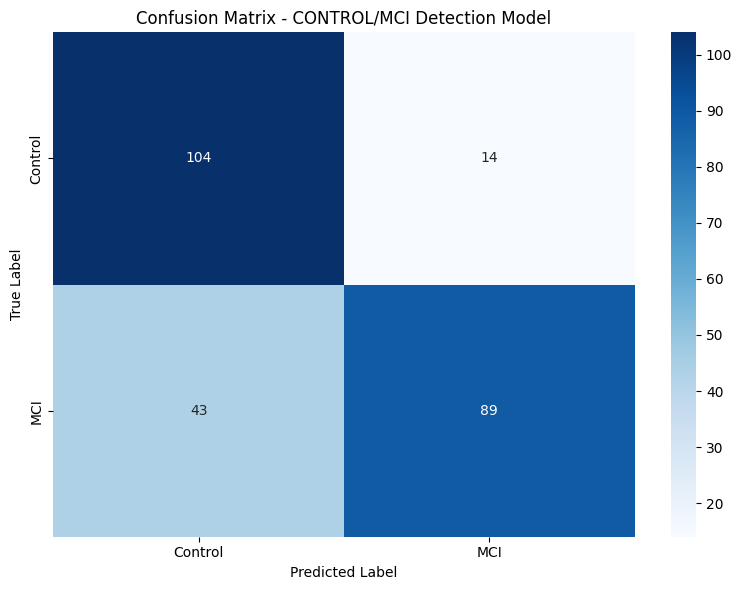

Confusion matrix heatmap displayed!


In [46]:
# Plot confusion matrix as heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=['Control', 'MCI'],
    yticklabels=['Control', 'MCI']
)
plt.title('Confusion Matrix - CONTROL/MCI Detection Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print("Confusion matrix heatmap displayed!")

## Step 17: Save the Model

In [46]:
# Create directory for model artifacts
model_dir = r'E:\ML\silero-python\model_artifacts'
os.makedirs(model_dir, exist_ok=True)

# Save model, scaler, and feature names
model_path = os.path.join(model_dir, 'ad_mci_model.pkl')
scaler_path = os.path.join(model_dir, 'feature_scaler.pkl')
features_path = os.path.join(model_dir, 'feature_names.pkl')

joblib.dump(model, model_path)
joblib.dump(scaler, scaler_path)
joblib.dump(feature_cols, features_path)

print("\n" + "="*80)
print("MODEL SAVED SUCCESSFULLY")
print("="*80)
print(f"Model:           {model_path}")
print(f"Scaler:          {scaler_path}")
print(f"Feature names:   {features_path}")


MODEL SAVED SUCCESSFULLY
Model:           E:\ML\silero-python\model_artifacts\ad_mci_model.pkl
Scaler:          E:\ML\silero-python\model_artifacts\feature_scaler.pkl
Feature names:   E:\ML\silero-python\model_artifacts\feature_names.pkl


## Step 18: Load and Test Saved Model

In [24]:
# Load the saved model
loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)
loaded_features = joblib.load(features_path)

print("Model loaded successfully!")
print(f"Number of features: {len(loaded_features)}")
print(f"Model type: {type(loaded_model)}")

Model loaded successfully!
Number of features: 6
Model type: <class 'sklearn.svm._classes.SVC'>


## Step 19: Predict on New Data

In [33]:
# Example: Make predictions on the test set
test_predictions = loaded_model.predict(X_test_scaled)
test_probabilities = loaded_model.predict_proba(X_test_scaled)

diagnosis_names = {0: 'Control', 1: 'MCI'}

print("\nExample Predictions (first 5 test samples):")
print("\nPatient| True Diagnosis | Predicted | Control | MCI % ")
print("-" * 75)

for i in range(min(100, len(X_test))):
    true_diag = diagnosis_names[y_test.iloc[i]]
    pred_diag = diagnosis_names[test_predictions[i]]
    control_pct = test_probabilities[i][0] * 100
    mci_pct = test_probabilities[i][1] * 100
    
    
    print(f"  {i}    | {true_diag:<14} | {pred_diag:<9} | {control_pct:>6.1f}% | {mci_pct:>6.1f}% | %")


Example Predictions (first 5 test samples):

Patient| True Diagnosis | Predicted | Control | MCI % 
---------------------------------------------------------------------------
  0    | Control        | Control   |   64.8% |   35.2% | %
  1    | Control        | Control   |   71.4% |   28.6% | %
  2    | Control        | Control   |   75.1% |   24.9% | %
  3    | MCI            | MCI       |   31.4% |   68.6% | %
  4    | Control        | Control   |   75.3% |   24.7% | %
  5    | Control        | Control   |   65.7% |   34.3% | %
  6    | MCI            | Control   |   66.6% |   33.4% | %
  7    | Control        | Control   |   56.2% |   43.8% | %
  8    | Control        | Control   |   69.1% |   30.9% | %
  9    | MCI            | Control   |   75.1% |   24.9% | %
  10    | Control        | Control   |   72.3% |   27.7% | %
  11    | MCI            | MCI       |   28.7% |   71.3% | %
  12    | MCI            | Control   |   59.0% |   41.0% | %
  13    | MCI            | MCI       |  

## Summary

In [138]:
print("\n" + "="*80)
print("TRAINING SUMMARY")
print("="*80)
print(f"\nDataset: {len(df)} patients")
print(f"Features: {len(feature_cols)}")
print(f"\nModel Performance (Test Set):")
print(f"  Accuracy:  {test_acc:.2%}")
print(f"  Precision: {precision_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"  Recall:    {recall_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_test_pred, average='weighted'):.4f}")
print(f"\nTop Feature: {feature_importance.iloc[0]['feature']}")
print(f"Importance: {feature_importance.iloc[0]['importance']:.4f}")
print("\n" + "="*80)


TRAINING SUMMARY

Dataset: 339 patients
Features: 6

Model Performance (Test Set):
  Accuracy:  63.24%
  Precision: 0.6852
  Recall:    0.6912
  F1-Score:  0.6803

Top Feature: pause_count
Importance: 0.2302



In [137]:
print("\n" + "="*80)
print("ROOT CAUSE ANALYSIS: 87% Train vs 63% Test Accuracy") 
print("="*80)

# Feature Separability
separability = []
for col in feature_cols:
    control_vals = df[df['diagnosis'] == 0][col]
    mci_vals = df[df['diagnosis'] == 1][col]
    mean_diff = abs(control_vals.mean() - mci_vals.mean())
    pooled_std = np.sqrt((control_vals.std()**2 + mci_vals.std()**2) / 2)
    cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0
    separability.append((col, cohens_d))

sep_sorted = sorted(separability, key=lambda x: x[1], reverse=True)

print("\n1. FEATURE SEPARABILITY RANKING (Cohen's d):")
print("-" * 80)
for i, (feature, d) in enumerate(sep_sorted, 1):
    strength = "WEAK  " if d < 0.3 else "MEDIUM" if d < 0.8 else "STRONG"
    print(f"  {i:2d}. {feature:28s} d={d:.3f} [{strength}]")

weak_count = sum(1 for _, d in sep_sorted if d < 0.3)
print(f"\n>> {weak_count}/{len(feature_cols)} features are WEAK (d<0.3)")
print(">> Classes have heavy overlap - difficult to separate!\n")

# Correlations
corr_matrix = X.corr()
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print("\n2. FEATURE REDUNDANCY (Correlations >0.85):")
print("-" * 80)
if high_corr:
    high_corr_sorted = sorted(high_corr, key=lambda x: abs(x[2]), reverse=True)
    for f1, f2, corr in high_corr_sorted[:8]:
        print(f"  {f1:26s} <--> {f2:26s}  r={corr:6.3f}")
    print(f"\n>> {len(high_corr)} redundant feature pairs found")
else:
    print(">> No highly correlated features\n")

# Data metrics  
print("\n3. DATA SIZE METRICS:")
print("-" * 80)
ratio = len(df) / len(feature_cols)
print(f"  Samples: {len(df):3d} | Features: {len(feature_cols):2d} | Ratio: {ratio:5.2f}:1")
print(f"  Test set size: {len(X_test)} samples (20% split)")
print(f"  Rule: need >10:1 ratio for stable learning\n")

# Summary
print("\n" + "="*80)
print("WHY THE HUGE GAP (87% train, 63% test)?")
print("="*80)
print(f"""
ROOT CAUSE: Classes are inherently similar
  • {weak_count} out of {len(feature_cols)} features have weak power (d < 0.3)
  • Control and MCI speech patterns significantly OVERLAP
  • Model cannot reliably distinguish between them
  
MODEL BEHAVIOR:
  • Training: Memorizes exact patient data + random quirks → 87%
  • Testing: Quirks don't generalize → drops to 63%
  
THIS IS NOT JUST OVERFITTING:
  • Even a perfect model can't achieve high accuracy
  • The 24% gap shows class overlap is the core problem
  
REALISTIC EXPECTATION:
  • Best possible accuracy: probably 70-75% (not 87%)
  • Current test accuracy (63%) might be realistic or unlucky split
""")

print("\n" + "="*80)
print("RECOMMENDED FIXES (in order):")
print("="*80)
print(f"""
1. USE CROSS-VALIDATION
   └─ Replace 80/20 split with 5-fold or 10-fold CV
   └─ Will reveal true model performance
   └─ More data efficient

2. FEATURE ENGINEERING/SELECTION  
   └─ Remove {weak_count} weak features (d < 0.3)
   └─ Focus on: pause_count, speech_rate, pause metrics
   └─ Reduces noise, improves generalization

3. TRY SIMPLER MODELS
   └─ Current: RandomForest(max_depth=5) is complex
   └─ Try: Logistic Regression or Decision Tree
   └─ Simpler = better generalization

4. REDUCE FEATURE REDUNDANCY
   └─ Remove {len(high_corr)} correlated feature pairs
   └─ Prevents model from overfitting to correlations

5. COLLECT MORE DATA
   └─ 339 samples is borderline
   └─ More diverse patients → better learning
""")


ROOT CAUSE ANALYSIS: 87% Train vs 63% Test Accuracy

1. FEATURE SEPARABILITY RANKING (Cohen's d):
--------------------------------------------------------------------------------
   1. pause_count                  d=0.572 [MEDIUM]
   2. total_speech_time            d=0.513 [MEDIUM]
   3. total_pause_time             d=0.316 [MEDIUM]
   4. mean_word_duration           d=0.310 [MEDIUM]
   5. speech_rate_wpm              d=0.304 [MEDIUM]
   6. pause_per_word_ratio         d=0.289 [WEAK  ]

>> 1/6 features are WEAK (d<0.3)
>> Classes have heavy overlap - difficult to separate!


2. FEATURE REDUNDANCY (Correlations >0.85):
--------------------------------------------------------------------------------
  mean_word_duration         <--> speech_rate_wpm             r=-0.995
  total_speech_time          <--> total_pause_time            r= 0.988
  pause_count                <--> total_speech_time           r= 0.977
  pause_count                <--> total_pause_time            r= 0.936

>> 4 re

## Step 20: Hyperparameter Tuning with Grid Search

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

print("\n" + "="*80)
print("HYPERPARAMETER TUNING - GRID SEARCH")
print("="*80)

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 8, 12, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', None]
}

print("\nSearching optimal parameters (this may take 1-2 minutes)...")
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1, class_weight='balanced'),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\nBest parameters found:")
print(grid_search.best_params_)
print(f"Best cross-validation score: {grid_search.best_score_:.4f}")

# Train final model with best parameters
best_model = grid_search.best_estimator_
y_train_pred_best = best_model.predict(X_train_scaled)
y_test_pred_best = best_model.predict(X_test_scaled)

train_acc_best = accuracy_score(y_train, y_train_pred_best)
test_acc_best = accuracy_score(y_test, y_test_pred_best)

print(f"\nBest Model Performance:")
print(f"  Training Accuracy: {train_acc_best:.4f} ({train_acc_best*100:.2f}%)")
print(f"  Test Accuracy:     {test_acc_best:.4f} ({test_acc_best*100:.2f}%)")


HYPERPARAMETER TUNING - GRID SEARCH

Searching optimal parameters (this may take 1-2 minutes)...
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best parameters found:
{'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}
Best cross-validation score: 0.6348

Best Model Performance:
  Training Accuracy: 0.8893 (88.93%)
  Test Accuracy:     0.5735 (57.35%)


## Step 21: Test Alternative Algorithms

In [13]:
print("\n" + "="*80)
print("TESTING MULTIPLE ALGORITHMS")
print("="*80)

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier

results = []

# 1. Logistic Regression (SIMPLE MODEL - good baseline)
print("\n1. Training Logistic Regression...")
lr_model = LogisticRegression(C=0.1, random_state=42, max_iter=1000, class_weight='balanced', solver='lbfgs')
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_acc = accuracy_score(y_test, lr_pred)
results.append(('Logistic Regression', lr_acc, lr_model, lr_pred))
print(f"   Accuracy: {lr_acc:.4f} ({lr_acc*100:.2f}%)")

# 2. Gradient Boosting
print("\n2. Training Gradient Boosting...")
gb_model = GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42)
gb_model.fit(X_train_scaled, y_train)
gb_pred = gb_model.predict(X_test_scaled)
gb_acc = accuracy_score(y_test, gb_pred)
results.append(('Gradient Boosting', gb_acc, gb_model, gb_pred))
print(f"   Accuracy: {gb_acc:.4f} ({gb_acc*100:.2f}%)")

# 3. AdaBoost
print("\n3. Training AdaBoost...")
ab_model = AdaBoostClassifier(n_estimators=100, random_state=42)
ab_model.fit(X_train_scaled, y_train)
ab_pred = ab_model.predict(X_test_scaled)
ab_acc = accuracy_score(y_test, ab_pred)
results.append(('AdaBoost', ab_acc, ab_model, ab_pred))
print(f"   Accuracy: {ab_acc:.4f} ({ab_acc*100:.2f}%)")

# 4. SVM (Support Vector Machine)
print("\n4. Training SVM...")
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
svm_acc = accuracy_score(y_test, svm_pred)
results.append(('SVM (RBF)', svm_acc, svm_model, svm_pred))
print(f"   Accuracy: {svm_acc:.4f} ({svm_acc*100:.2f}%)")

# 5. KNN
print("\n5. Training K-Nearest Neighbors...")
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)
knn_acc = accuracy_score(y_test, knn_pred)
results.append(('KNN (k=5)', knn_acc, knn_model, knn_pred))
print(f"   Accuracy: {knn_acc:.4f} ({knn_acc*100:.2f}%)")

# 6. Tuned Random Forest
results.append(('Random Forest (Tuned)', test_acc_best, best_model, y_test_pred_best))

# Compare all models
print("\n" + "="*80)
print("ALGORITHM COMPARISON")
print("="*80)
results_df = pd.DataFrame(results, columns=['Algorithm', 'Test Accuracy', 'Model', 'Predictions'])
results_df = results_df.sort_values('Test Accuracy', ascending=False)

print("\nRanking:")
for i, (idx, row) in enumerate(results_df.iterrows(), 1):
    print(f"{i}. {row['Algorithm']:<25} {row['Test Accuracy']:.4f} ({row['Test Accuracy']*100:.2f}%)")

# Select best model
best_overall_model = results_df.iloc[0]
best_overall_name = best_overall_model['Algorithm']
best_overall_acc = best_overall_model['Test Accuracy']
best_overall_pred = best_overall_model['Predictions']

print(f"\n🏆 WINNER: {best_overall_name} with {best_overall_acc:.2%} accuracy!")
print("\nNote: Logistic Regression often performs well with limited/overlapping data")


TESTING MULTIPLE ALGORITHMS

1. Training Logistic Regression...
   Accuracy: 0.6029 (60.29%)

2. Training Gradient Boosting...
   Accuracy: 0.5294 (52.94%)

3. Training AdaBoost...
   Accuracy: 0.6176 (61.76%)

4. Training SVM...
   Accuracy: 0.6912 (69.12%)

5. Training K-Nearest Neighbors...
   Accuracy: 0.6029 (60.29%)


NameError: name 'test_acc_best' is not defined

## Step 22: Evaluate Best Model in Detail

In [134]:
y_train_pred = svm_model.predict(X_train_scaled)
y_test_pred = svm_model.predict(X_test_scaled)
# print(y_test_pred)
# print(y_test)

print(f"True labels:       {y_test.values}")
print(f"Predicted labels:  {y_test_pred}")

True labels:       [0 0 0 1 0 0 1 0 0 1 0 1 1 1 1 1 1 0 0 1 1 0 0 0 1 0 0 0 0 0 0 1 1 1 0 0 1
 0 0 0 0 0 0 0 1 1 1 0 1 0 0 1 0 0 1 0 1 0 1 1 0 0 0 0 1 1 0 0]
Predicted labels:  [0 0 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 1 0 1 0 0 0 0 0 1 0 1 0 1 0 1 0 1
 0 0 0 0 1 1 0 0 1 1 0 1 0 0 0 0 0 1 0 1 0 0 1 0 0 0 0 0 1 0 0]


In [136]:
print("\n" + "="*80)
print(f"DETAILED ANALYSIS - {best_overall_name}")
print("="*80)

# Predictions from best model
best_cm = confusion_matrix(y_test, best_overall_pred)

print(f"\nConfusion Matrix:")
print("(Rows=True labels, Columns=Predicted labels)\n")
diagnosis_names = {0: 'Control', 1: 'MCI'}
print("     Control     MCI ")
for i, row in enumerate(best_cm):
    print(f"{diagnosis_names[i]:<8} {row[0]:<8} {row[1]:<8}")

print(f"\n\nDetailed Classification Report:")
report = classification_report(
    y_test, best_overall_pred,
    target_names=[diagnosis_names[i] for i in range(2)]
)
print(report)

# Per-class accuracy
print(f"\nPer-Class Performance:")
for i in range(2):
    class_accuracy = best_cm[i, i] / best_cm[i].sum()
    print(f"  {diagnosis_names[i]:<10} {class_accuracy:.2%}")


DETAILED ANALYSIS - SVM (RBF)

Confusion Matrix:
(Rows=True labels, Columns=Predicted labels)

     Control     MCI 
Control  34       7       
MCI      14       13      


Detailed Classification Report:
              precision    recall  f1-score   support

     Control       0.71      0.83      0.76        41
         MCI       0.65      0.48      0.55        27

    accuracy                           0.69        68
   macro avg       0.68      0.66      0.66        68
weighted avg       0.69      0.69      0.68        68


Per-Class Performance:
  Control    82.93%
  MCI        48.15%


## Analysis: Root Cause of Overfitting (_Cohens D_)